# Freight Lane Network Analysis

**A network-theoretic view of a freight forwarding branch's lane portfolio.**

This notebook treats the branch's set of shipping lanes as a directed graph and uses graph-theory tools to surface insights that are invisible in a tabular view: hub structure, route bottlenecks, redundancy, and structural fragility.

---

**Author:** Harshaa Nandakumar  ·  [harshaanandakumar.github.io](https://harshaanandakumar.github.io)
**Stack:** Python · pandas · NetworkX · Matplotlib


## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load lane data — origin, destination, mode, transit days
lanes = pd.read_csv('../data/lanes.csv')
print(f"Loaded {len(lanes)} lanes")
lanes


Loaded 10 lanes


,lane_id,origin,destination,mode,transit_days
0,1,MAA,Shanghai,Sea,18
1,2,MAA,Frankfurt,Air,3
2,3,HKG,MAA,Air,2
3,4,MAA,Rotterdam,Sea,24
4,5,MAA,New York,Sea,32
5,6,MAA,Dubai,Sea,7
6,7,Singapore,MAA,Sea,5
7,8,MAA,Hamburg,Sea,26
8,9,MAA,Tokyo,Air,5
9,10,Shanghai,MAA,Sea,18


## 2. Network composition

In [2]:
# Quick network stats
all_ports = sorted(pd.concat([lanes['origin'], lanes['destination']]).unique())
print(f"Ports in network: {len(all_ports)}")
print(f"Modes:            {lanes['mode'].unique().tolist()}")
print(f"Transit range:    {lanes['transit_days'].min()}-{lanes['transit_days'].max()} days\n")

# Connections per port (manual — we'll cross-check with networkx in cell 3)
print("Connections per port:")
for p in all_ports:
    out_count = (lanes['origin'] == p).sum()
    in_count  = (lanes['destination'] == p).sum()
    print(f"  {p:12} {out_count + in_count:>2}  ({out_count} out, {in_count} in)")


Ports in network: 10
Modes:            ['Sea', 'Air']
Transit range:    2-32 days

Connections per port:
  Dubai         1  (0 out, 1 in)
  Frankfurt     1  (0 out, 1 in)
  HKG           1  (1 out, 0 in)
  Hamburg       1  (0 out, 1 in)
  MAA          10  (7 out, 3 in)
  New York      1  (0 out, 1 in)
  Rotterdam     1  (0 out, 1 in)
  Shanghai      2  (1 out, 1 in)
  Singapore     1  (1 out, 0 in)
  Tokyo         1  (0 out, 1 in)


## 3. Build the directed graph

Each lane becomes a directed edge. Mode and transit days are attached as edge attributes.

In [3]:
G = nx.DiGraph()

for _, row in lanes.iterrows():
    G.add_edge(
        row['origin'],
        row['destination'],
        mode=row['mode'],
        transit_days=row['transit_days'],
        lane_id=row['lane_id']
    )

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"\nSample edge attributes — MAA → Shanghai:")
print(f"  {G['MAA']['Shanghai']}")


Nodes: 10
Edges: 10

Sample edge attributes — MAA → Shanghai:
  {'mode': 'Sea', 'transit_days': 18, 'lane_id': 1}


## 4. Network visualization

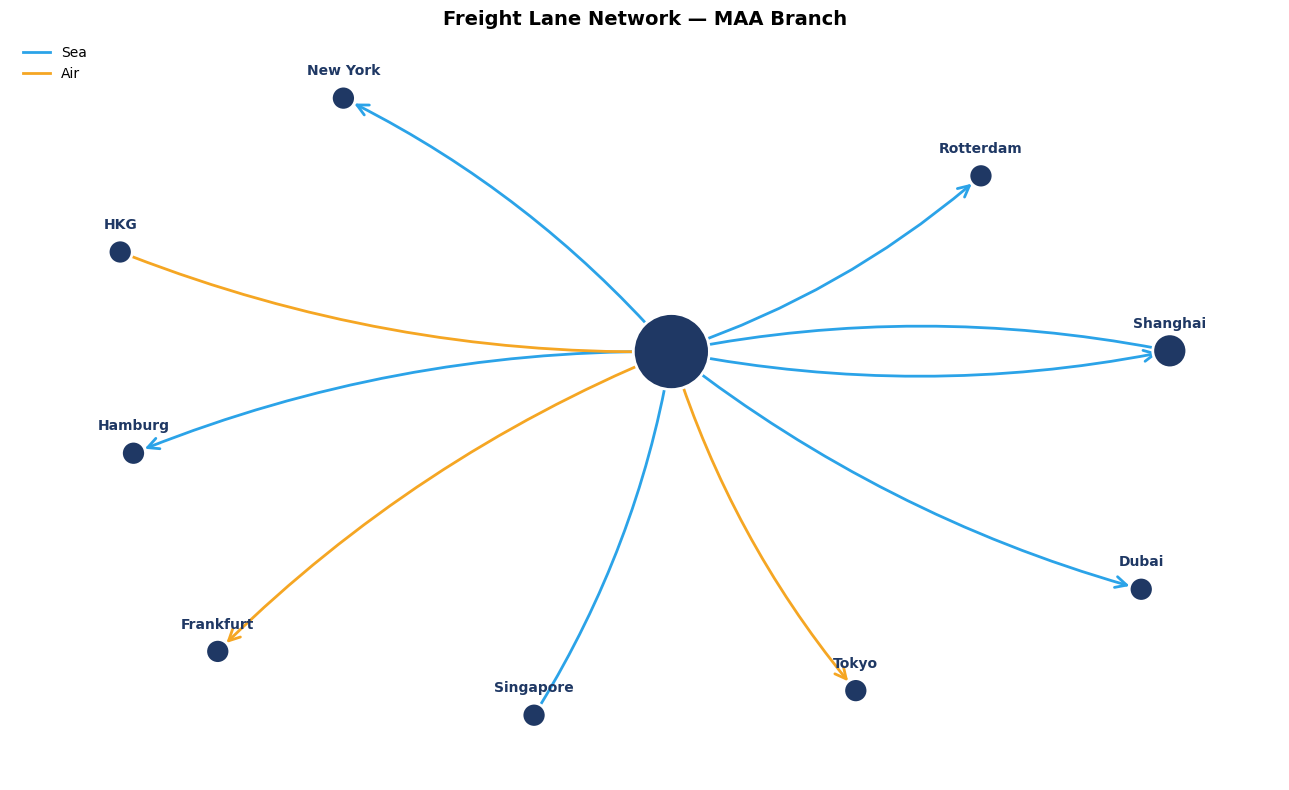

In [4]:
pos = nx.spring_layout(G, seed=42, k=2)

# Node size proportional to degree
node_sizes = [G.degree(n) * 300 for n in G.nodes()]

# Edge color by mode
edge_colors = ['#2BA3E8' if G[u][v]['mode'] == 'Sea' else '#F5A623'
               for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(13, 8))

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                       node_color='#1F3864', edgecolors='white', linewidths=2)

# Labels positioned just above nodes to avoid clipping
label_pos = {n: (pos[n][0], pos[n][1] + 0.08) for n in G.nodes()}
nx.draw_networkx_labels(G, label_pos, ax=ax,
                        font_size=10, font_color='#1F3864', font_weight='bold')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=2,
                       arrows=True, arrowsize=20, arrowstyle='->',
                       connectionstyle='arc3,rad=0.1')

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#2BA3E8', lw=2, label='Sea'),
    Line2D([0], [0], color='#F5A623', lw=2, label='Air'),
], loc='upper left', frameon=False)

ax.set_title('Freight Lane Network — MAA Branch', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


## 5. Centrality analysis

Four definitions of "important," each answering a different question:

- **Degree** — how many connections does this port have?
- **Betweenness** — does traffic pass through this port?
- **Closeness** — can this port reach others quickly?
- **Eigenvector** — is this port connected to other well-connected ports?


In [5]:
centrality_df = pd.DataFrame({
    'port':         list(G.nodes()),
    'degree':       [round(nx.degree_centrality(G)[n], 3)         for n in G.nodes()],
    'betweenness':  [round(nx.betweenness_centrality(G)[n], 3)    for n in G.nodes()],
    'closeness':    [round(nx.closeness_centrality(G)[n], 3)      for n in G.nodes()],
    'eigenvector':  [round(nx.eigenvector_centrality(G, max_iter=1000)[n], 3) for n in G.nodes()],
})

centrality_df = centrality_df.sort_values('degree', ascending=False).reset_index(drop=True)
centrality_df


,port,degree,betweenness,closeness,eigenvector
0,MAA,1.111,0.278,0.333,0.354
1,Shanghai,0.222,0.000,0.200,0.354
2,Frankfurt,0.111,0.000,0.254,0.354
3,HKG,0.111,0.000,0.000,0.000
4,Rotterdam,0.111,0.000,0.254,0.354
5,New York,0.111,0.000,0.254,0.354
6,Dubai,0.111,0.000,0.254,0.354
7,Singapore,0.111,0.000,0.000,0.000
8,Hamburg,0.111,0.000,0.254,0.354
9,Tokyo,0.111,0.000,0.254,0.354


## 6. Network-level diagnostics

In [6]:
print(f"Density:            {nx.density(G):.3f}")
print(f"Weakly connected:   {nx.is_weakly_connected(G)}")
print(f"Strongly connected: {nx.is_strongly_connected(G)}")

# Top hub via betweenness
top_betw = max(nx.betweenness_centrality(G), key=nx.betweenness_centrality(G).get)
print(f"\nHighest-betweenness port: {top_betw}")


Density:            0.111
Weakly connected:   True
Strongly connected: False

Highest-betweenness port: MAA


## 7. Path analysis

Two question types: *can I get from A to B?* and *what's the fastest route?*

In [7]:
def find_path(graph, source, target, weight=None):
    """Return shortest path or None if no path exists."""
    try:
        path = nx.shortest_path(graph, source=source, target=target, weight=weight)
        length = nx.shortest_path_length(graph, source=source, target=target, weight=weight)
        return path, length
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None, None


# Hop-count routing
for src, tgt in [('Frankfurt', 'Tokyo'), ('Tokyo', 'Frankfurt'), ('HKG', 'Rotterdam')]:
    path, hops = find_path(G, src, tgt)
    if path:
        print(f"{src:10} → {tgt:12}  [{hops} hops]   {' → '.join(path)}")
    else:
        print(f"{src:10} → {tgt:12}  no path")

# Weighted routing — fastest by transit days
print()
path, days = find_path(G, 'HKG', 'Rotterdam', weight='transit_days')
print(f"HKG → Rotterdam (fastest by transit days): {' → '.join(path)}  [{days} days]")


Frankfurt  → Tokyo         no path
Tokyo      → Frankfurt     no path
HKG        → Rotterdam     [2 hops]   HKG → MAA → Rotterdam

HKG → Rotterdam (fastest by transit days): HKG → MAA → Rotterdam  [26 days]


## 8. Systematic fragility scoring

For each edge, simulate its failure and measure connectivity loss across the whole network.

In [8]:
def score_all_edges_by_blast_radius(graph):
    """For every edge, count how many origin-destination routes break if it's removed."""
    nodes = list(graph.nodes())
    baseline = sum(1 for s in nodes for d in nodes
                   if s != d and nx.has_path(graph, s, d))

    results = []
    for u, v in graph.edges():
        Gx = graph.copy()
        Gx.remove_edge(u, v)
        still = sum(1 for s in nodes for d in nodes
                    if s != d and nx.has_path(Gx, s, d))
        broken = baseline - still
        results.append({
            'origin': u,
            'destination': v,
            'mode': graph[u][v].get('mode'),
            'transit_days': graph[u][v].get('transit_days'),
            'routes_broken': broken,
            'blast_radius_pct': round(100 * broken / baseline, 1) if baseline else 0,
        })

    return pd.DataFrame(results).sort_values('blast_radius_pct', ascending=False).reset_index(drop=True)


fragility_df = score_all_edges_by_blast_radius(G)
fragility_df


,origin,destination,mode,transit_days,routes_broken,blast_radius_pct
0,Singapore,MAA,Sea,5,8,26.7
1,HKG,MAA,Air,2,8,26.7
2,Shanghai,MAA,Sea,18,7,23.3
3,MAA,Frankfurt,Air,3,4,13.3
4,MAA,Hamburg,Sea,26,4,13.3
5,MAA,Rotterdam,Sea,24,4,13.3
6,MAA,New York,Sea,32,4,13.3
7,MAA,Dubai,Sea,7,4,13.3
8,MAA,Tokyo,Air,5,4,13.3
9,MAA,Shanghai,Sea,18,3,10.0


## 9. Three-factor fragility model

Blast radius alone tells us "how big is the fire if it starts." Real fragility is a combination of three factors:

| Factor | Question | Source |
|---|---|---|
| Blast radius | If this lane fails, what % of routes break? | Computed in cell 8 |
| Failure probability | How likely is this lane to fail? | Heuristic from mode + transit days |
| Redundancy | Is there a backup path? | Count of alternate routes |

> **Note on the probability heuristic:** in production this would be replaced with carrier-specific historical on-time data. The heuristic here gives a relative ordering; absolute numbers shouldn't be taken as predictions.


In [9]:
def estimate_failure_probability(mode, transit_days):
    """Heuristic: Air slightly more disruption-prone; long sea routes accumulate weather risk."""
    base = 0.08 if mode == 'Air' else 0.05
    if transit_days and transit_days > 10:
        base += (transit_days - 10) * 0.005
    return round(min(base, 0.30), 3)


def count_alternate_paths(graph, u, v, cutoff=4):
    """Number of paths from u to v with the direct edge removed."""
    Gx = graph.copy()
    if Gx.has_edge(u, v):
        Gx.remove_edge(u, v)
    try:
        return len(list(nx.all_simple_paths(Gx, u, v, cutoff=cutoff)))
    except nx.NodeNotFound:
        return 0


def compute_fragility_score(graph):
    """Combine blast radius, probability, and redundancy into a single score."""
    df = score_all_edges_by_blast_radius(graph)

    df['failure_prob'] = df.apply(
        lambda r: estimate_failure_probability(r['mode'], r['transit_days']),
        axis=1
    )
    df['alternate_paths'] = df.apply(
        lambda r: count_alternate_paths(graph, r['origin'], r['destination']),
        axis=1
    )
    df['fragility_score'] = (
        df['blast_radius_pct'] *
        df['failure_prob'] *
        (1 / (1 + df['alternate_paths']))
    ).round(3)

    return df.sort_values('fragility_score', ascending=False).reset_index(drop=True)


full_fragility = compute_fragility_score(G)
full_fragility


,origin,destination,mode,transit_days,routes_broken,blast_radius_pct,failure_prob,alternate_paths,fragility_score
0,HKG,MAA,Air,2,8,26.7,0.08,0,2.136
1,MAA,New York,Sea,32,4,13.3,0.16,0,2.128
2,Shanghai,MAA,Sea,18,7,23.3,0.09,0,2.097
3,MAA,Hamburg,Sea,26,4,13.3,0.13,0,1.729
4,MAA,Rotterdam,Sea,24,4,13.3,0.12,0,1.596
5,Singapore,MAA,Sea,5,8,26.7,0.05,0,1.335
6,MAA,Frankfurt,Air,3,4,13.3,0.08,0,1.064
7,MAA,Tokyo,Air,5,4,13.3,0.08,0,1.064
8,MAA,Shanghai,Sea,18,3,10.0,0.09,0,0.900
9,MAA,Dubai,Sea,7,4,13.3,0.05,0,0.665


## 10. Risk-coded network visualization

Top-3 fragile lanes highlighted in red. Score boxes show the composite fragility number.

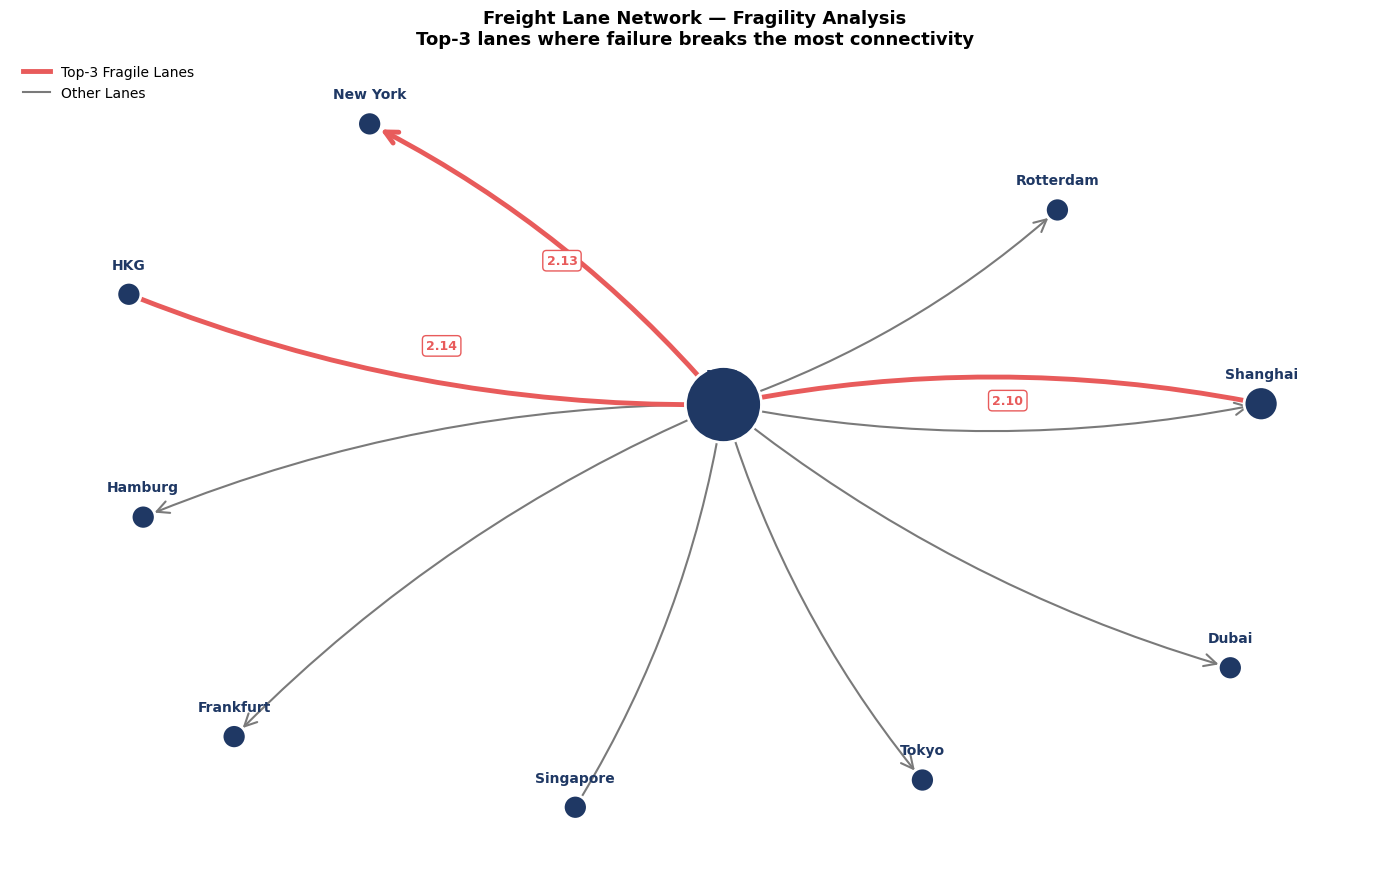

In [10]:
fragility_lookup = {
    (r['origin'], r['destination']): r['fragility_score']
    for _, r in full_fragility.iterrows()
}
top_3 = [tuple(p) for p in full_fragility.head(3)[['origin', 'destination']].values.tolist()]


def edge_style(u, v):
    if (u, v) in top_3:
        return '#E85B5B', 3.5  # red, thick
    return '#7A7A7A', 1.5      # grey, thin


edge_colors = [edge_style(u, v)[0] for u, v in G.edges()]
edge_widths = [edge_style(u, v)[1] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(14, 9))

nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_size=[G.degree(n) * 300 for n in G.nodes()],
                       node_color='#1F3864', edgecolors='white', linewidths=2)

label_pos = {n: (pos[n][0], pos[n][1] + 0.08) for n in G.nodes()}
nx.draw_networkx_labels(G, label_pos, ax=ax,
                        font_size=10, font_color='#1F3864', font_weight='bold')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowsize=22, arrowstyle='->',
                       connectionstyle='arc3,rad=0.1')

# Annotate top-3 edges with score
for u, v in top_3:
    mid_x = (pos[u][0] + pos[v][0]) / 2
    mid_y = (pos[u][1] + pos[v][1]) / 2
    ax.text(mid_x, mid_y, f"{fragility_lookup[(u, v)]:.2f}",
            fontsize=9, fontweight='bold', color='#E85B5B',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#E85B5B', linewidth=1))

ax.legend(handles=[
    Line2D([0], [0], color='#E85B5B', lw=3.5, label='Top-3 Fragile Lanes'),
    Line2D([0], [0], color='#7A7A7A', lw=1.5, label='Other Lanes'),
], loc='upper left', frameon=False, fontsize=10)

ax.set_title('Freight Lane Network — Fragility Analysis\n'
             'Top-3 lanes where failure breaks the most connectivity',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


## 11. Key findings

1. **MAA is the only structural hub.** Every other port has zero betweenness centrality — they are terminal nodes, not transit nodes. The network is pure hub-and-spoke.

2. **Inbound-only ports are the structural weakness.** HKG, Singapore, and Shanghai inbound lanes each break 23–27% of network connectivity if they fail, because no alternate entry exists. Outbound MAA → leaf lanes break only ~13% on failure.

3. **Asymmetric damage.** Losing `Shanghai → MAA` is twice as damaging as losing `MAA → Shanghai`, despite being the same port pair. Inbound edges to a hub carry more network weight than outbound.

4. **Density at 11% is healthy for a specialized branch.** Higher density would imply unfocused operations; lower would imply over-concentration. The shape matches a Chennai export-focused branch.

### Recommendations

- **Highest priority:** Add a second inbound corridor to HKG (e.g., HKG → Singapore → MAA via partner carrier). Single fix addresses three fragile entry points via transitive paths.
- **Watch list:** MAA → New York. Long transit (32 days) means high failure probability despite modest blast radius.
- **Strategic monitoring:** Shanghai. Only port with bidirectional connectivity — worth investigating whether this reflects volume, customer preference, or strategic intent.

### Methodology notes

The probability heuristic and redundancy count are documented limitations of this analysis — see [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md) for the full discussion of where the model would need real data to harden up for production use.
